In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [64]:
X_train = pd.read_csv('data/X_train.csv')
X_valid = pd.read_csv('data/X_valid.csv')
Y_train = pd.read_csv('data/Y_train.csv')
Y_valid = pd.read_csv('data/Y_valid.csv')

In [65]:
X_train

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1010.8,24.3,21.4,20.4,19.5,86.0,77.0,7.3,9.5,0.985139,...,-60.7,2464.7,3.4,0.3,28.8,-27.2,27.2,23.6,0.0,127.2
1,1012.0,26.5,24.4,23.3,22.2,90.0,88.0,0.6,37.5,0.908324,...,-70.8,1197.9,6.4,0.2,17.4,-11.1,11.1,53.0,0.2,14.2
2,1013.5,28.9,26.5,24.8,20.6,76.0,54.0,4.5,16.7,-0.970942,...,-50.6,2410.5,2.8,0.4,32.4,-27.1,27.1,82.8,0.1,11.6
3,1013.9,20.9,20.6,19.4,19.9,73.0,83.0,2.0,14.8,0.495009,...,-48.8,1207.3,4.0,0.6,23.7,-16.0,16.0,94.4,0.2,3.4
4,1013.4,27.8,24.4,23.1,22.1,87.0,88.0,1.6,13.0,0.974928,...,-69.2,1250.3,6.6,0.2,15.1,-14.5,14.5,4.4,0.0,55.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1744,1010.7,30.8,28.7,27.6,25.3,78.0,51.0,9.2,20.5,0.017261,...,-54.4,1352.3,4.0,0.3,22.1,-14.3,14.3,73.3,0.2,7.6
1745,1014.3,15.6,13.8,10.0,7.8,78.0,77.0,3.5,41.3,0.051761,...,-62.7,3266.8,3.4,0.4,34.3,-34.3,34.3,0.0,0.0,0.0
1746,1014.9,23.3,21.6,20.9,20.9,87.0,88.0,0.0,15.1,0.609902,...,-55.8,2132.4,3.9,0.3,27.8,-22.7,22.7,28.6,0.2,0.5
1747,1011.4,31.4,28.9,26.7,24.5,81.0,88.0,2.2,22.5,-0.338413,...,-40.5,731.7,5.2,0.3,21.9,-6.5,6.5,102.8,0.7,2.0


In [67]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, Y_train.values.reshape(-1))
Y_pred = rf.predict_proba(X_valid)[:,1]
roc_auc_score(Y_valid, Y_pred)

np.float64(0.8755682299460711)

In [68]:
# feature importance
importances = rf.feature_importances_
features_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)


In [69]:
features_importance.sort_values(ascending=False, inplace=True)

In [70]:
auc_scores = []

for i in range(1, len(features_importance), 50):
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train[features_importance[:i].index], Y_train.values.reshape(-1))
    Y_pred = rf.predict_proba(X_valid[features_importance[:i].index])[:,1]
    auc_scores.append(roc_auc_score(Y_valid, Y_pred))
    print(i, roc_auc_score(Y_valid, Y_pred))

1 0.8281757348166134
51 0.8831916876076462
101 0.888316345257927
151 0.8778835022729199
201 0.8742411836123896
251 0.8761470480277833
301 0.8755823474602592
351 0.874325888697518
401 0.8765423384250501
451 0.875963520343338
501 0.8787870231809582
551 0.8689471157918512
601 0.8753423497190614
651 0.8765705734534264
701 0.8741141259846966
751 0.875822345201457
801 0.8742270660982014
851 0.8795211339187395
901 0.8822458141570432
951 0.8798881892876302
1001 0.8702882796397211
1051 0.8722223790834911
1101 0.8765423384250501
1151 0.8815964085043906
1201 0.8778835022729197
1251 0.8791964310924133


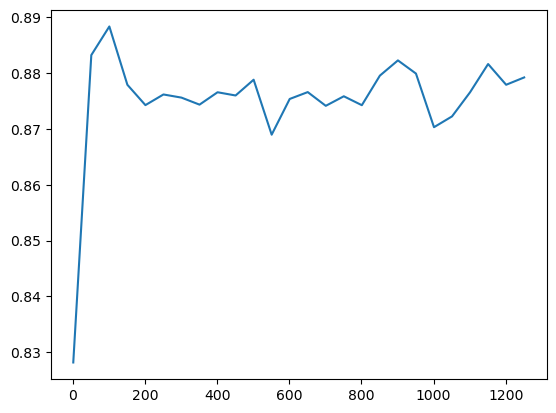

In [71]:
plt.plot(range(1, len(features_importance), 50), auc_scores)

In [72]:
int(pd.Series(auc_scores).idxmax()) * 50 + 1

101

In [73]:
auc_scores_better = []

for i in range(1, 200, 10):
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train[features_importance[:i].index], Y_train.values.reshape(-1))
    Y_pred = rf.predict_proba(X_valid[features_importance[:i].index])[:,1]
    auc_scores_better.append(roc_auc_score(Y_valid, Y_pred))
    print(i, roc_auc_score(Y_valid, Y_pred))

1 0.8281757348166134
11 0.8797893666883136
21 0.8718270886862242
31 0.8768529237371884
41 0.883883445802863
51 0.8831916876076462
61 0.8885704605133129
71 0.8841940311150013
81 0.8882598752011748
91 0.8839681508879915
101 0.888316345257927
111 0.8805234774260948
121 0.879732896631561
131 0.8811728830787475
141 0.8842081486291894
151 0.8778835022729199
161 0.8793799587768586
171 0.8792387836349775
181 0.8790834909789085
191 0.8769093937939407


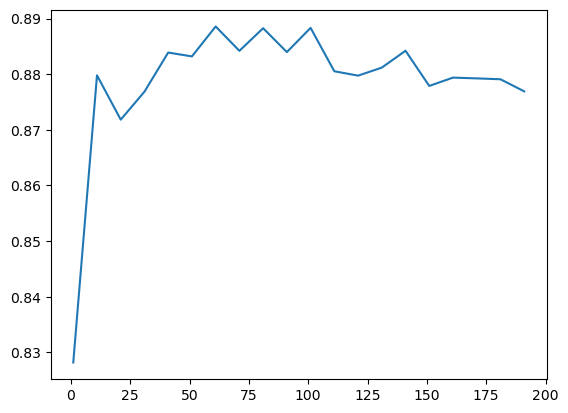

In [74]:
plt.plot(range(1, 200, 10), auc_scores_better)

In [75]:
int(pd.Series(auc_scores_better).idxmax()) * 10 + 1

61

In [76]:
auc_scores_better2 = []

for i in range(25, 125, 2):
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train[features_importance[:i].index], Y_train.values.reshape(-1))
    Y_pred = rf.predict_proba(X_valid[features_importance[:i].index])[:,1]
    auc_scores_better2.append(roc_auc_score(Y_valid, Y_pred))
    print(i, roc_auc_score(Y_valid, Y_pred))

25 0.8767399836236837
27 0.8783634977553153
29 0.8760058728859024
31 0.8768529237371884
33 0.8769658638506932
35 0.8829375723522602
37 0.8852246096507328
39 0.8867069486404833
41 0.883883445802863
43 0.8807352401389164
45 0.8847022616257729
47 0.888048112488353
49 0.8835305079481605
51 0.8831916876076462
53 0.8839681508879917
55 0.8871163565519382
57 0.8838975633170513
59 0.8828105147245674
61 0.8885704605133129
63 0.8860716605020189
65 0.8838128582319225
67 0.8847022616257729
69 0.8853234322500494
71 0.8841940311150013
73 0.8845893215122681
75 0.8871728266086907
77 0.8861846006155237
79 0.8898975068469945
81 0.8882598752011748
83 0.8878504672897196
85 0.8891916311375893
87 0.8813987633057571
89 0.885563429991247
91 0.8839681508879915
93 0.8886834006268176
95 0.8828387497529435
97 0.885676370104752
99 0.8849422593669707
101 0.888316345257927
103 0.8854504898777424
105 0.8834034503204676
107 0.8824716943840529
109 0.8841657960866249
111 0.8805234774260948
113 0.8822458141570433
115 0.88

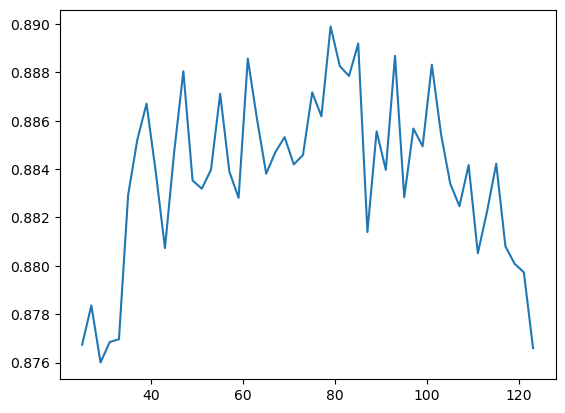

In [77]:
plt.plot(range(25, 125, 2), auc_scores_better2)

In [79]:
int(pd.Series(auc_scores_better2).idxmax()) * 2 + 25

79

In [80]:
# XGBoost Classifier
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, random_state=42)
xgb.fit(X_train[features_importance[:80].index], Y_train.values.reshape(-1))
Y_pred = xgb.predict_proba(X_valid[features_importance[:80].index])[:,1]
roc_auc_score(Y_valid, Y_pred)

np.float64(0.8712482706045119)

In [53]:
df_test = pd.read_csv('data/test_prev.csv')
df_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,50.6,6.880243e-02,...,-72.5,2507.6,4.2,0.3,25.5,-25.5,25.5,0.0,0.0,0.0
1,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,19.4,8.596480e-02,...,-45.7,2464.7,3.1,0.6,36.6,-31.9,31.9,119.8,0.0,2.4
2,1027.1,15.6,12.6,11.5,9.0,76.0,94.0,0.0,41.4,1.031017e-01,...,-34.4,1616.7,3.0,0.6,34.4,-23.5,23.5,179.2,0.2,3.1
3,1022.6,15.5,13.7,10.7,11.8,79.0,95.0,0.0,43.1,1.202080e-01,...,-25.5,2373.1,1.9,0.7,42.6,-31.7,31.7,179.2,0.2,3.1
4,1013.5,20.5,16.2,15.2,13.1,94.0,93.0,0.2,41.3,1.372788e-01,...,-44.7,2978.9,2.3,0.4,37.7,-31.6,31.6,59.5,0.2,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,34.3,-6.880243e-02,...,-63.5,2319.4,3.5,0.3,25.9,-25.8,25.8,1.6,0.0,39.2
723,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,25.2,-5.161967e-02,...,-63.5,2747.5,3.2,0.3,29.5,-29.5,29.5,0.0,0.0,0.0
724,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,21.9,-3.442161e-02,...,-60.8,2651.2,3.1,0.3,29.8,-28.7,28.7,13.4,0.0,5.2
725,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,39.5,-1.721336e-02,...,-63.2,2459.0,3.4,0.3,27.7,-26.6,26.6,13.4,0.0,5.2


In [58]:
df_train = pd.read_csv('data/train_prev.csv')
df_Y_train = df_train['rainfall']
df_X_train = df_train.drop('rainfall', axis=1)
df_train.drop(['rainfall', 'prev1_rainfall'], axis=1, inplace=True)

df_train

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,5.176135e-02,...,-56.3,1452.4,4.0,0.3,22.2,-15.9,15.9,56.4,0.2,5.9
1,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,6.899114e-02,...,-52.5,2075.2,3.1,0.3,28.0,-22.4,22.4,50.1,0.2,0.7
2,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,15.7,8.620038e-02,...,-36.2,1782.9,2.4,0.4,30.1,-22.2,22.2,79.8,0.2,3.0
3,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,28.4,1.033839e-01,...,-48.3,1923.2,3.2,0.4,26.6,-24.2,24.2,29.8,0.0,2.3
4,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,52.8,1.205367e-01,...,-34.4,1231.4,2.9,0.5,26.7,-19.2,19.2,101.7,0.1,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2182,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,22.1,-6.899114e-02,...,-55.7,2677.3,2.9,0.4,32.2,-29.8,29.8,41.0,0.0,11.5
2183,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,35.3,-5.176135e-02,...,-56.4,2609.9,3.0,0.4,31.1,-29.4,29.4,31.1,0.0,78.9
2184,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,32.9,-3.451614e-02,...,-58.7,2581.3,3.1,0.3,29.4,-29.3,29.3,0.7,0.0,73.7
2185,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,18.0,-1.726064e-02,...,-54.9,2550.1,3.0,0.4,31.8,-28.4,28.4,55.6,0.1,75.9


In [87]:
df_test = pd.read_csv('data/test_prev.csv')

df_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,24.3,1.721336e-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,35.3,3.442161e-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,16.9,5.161967e-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,50.6,6.880243e-02,...,-72.5,2507.6,4.2,0.3,25.5,-25.5,25.5,0.0,0.0,0.0
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,19.4,8.596480e-02,...,-45.7,2464.7,3.1,0.6,36.6,-31.9,31.9,119.8,0.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,34.3,-6.880243e-02,...,-63.5,2319.4,3.5,0.3,25.9,-25.8,25.8,1.6,0.0,39.2
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,25.2,-5.161967e-02,...,-63.5,2747.5,3.2,0.3,29.5,-29.5,29.5,0.0,0.0,0.0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,21.9,-3.442161e-02,...,-60.8,2651.2,3.1,0.3,29.8,-28.7,28.7,13.4,0.0,5.2
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,39.5,-1.721336e-02,...,-63.2,2459.0,3.4,0.3,27.7,-26.6,26.6,13.4,0.0,5.2


In [88]:
pd.Series(df_train.columns)[pd.Series(df_train.columns).apply(lambda x: x not in df_test.columns)]

Series([], dtype: object)

In [89]:
# train on the entire dataset (df_train) using Random Forest

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(df_X_train[features_importance[:80].index], df_Y_train.values.reshape(-1))
Y_test_pred = rf.predict_proba(df_test[features_importance[:80].index])[:,1]

In [90]:
# change column names to id, rainfall for Y_test_pred
Y_test_pred = pd.DataFrame(Y_test_pred, columns=['rainfall'])
Y_test_pred['id'] = pd.read_csv('data/test.csv')['id']
Y_test_pred = Y_test_pred[['id', 'rainfall']]
pd.DataFrame(Y_test_pred).to_csv('data/pred_RF.csv', index=False)

In [91]:
# train on the entire dataset (df_train) using XGBoost

xgb = XGBClassifier(n_estimators=300, random_state=42)
xgb.fit(df_X_train[features_importance[:80].index], df_Y_train.values.reshape(-1))
Y_test_pred2 = xgb.predict_proba(df_test[features_importance[:80].index])[:,1]

In [92]:
# change column names to id, rainfall for Y_test_pred2
Y_test_pred2 = pd.DataFrame(Y_test_pred2, columns=['rainfall'])
Y_test_pred2['id'] = pd.read_csv('data/test.csv')['id']
Y_test_pred2 = Y_test_pred2[['id', 'rainfall']]
pd.DataFrame(Y_test_pred2).to_csv('data/pred_XGBoost.csv', index=False)